In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("✅ Tüm kütüphaneler başarıyla yüklendi!")
print(f"Pandas versiyon: {pd.__version__}")
print(f"NumPy versiyon: {np.__version__}")

✅ Tüm kütüphaneler başarıyla yüklendi!
Pandas versiyon: 3.0.3
NumPy versiyon: 2.5.0


In [2]:
# TSB Gerçek Verilerine Dayalı Trafik Sigortası Veri Seti
# Kaynak: Türkiye Sigorta Birliği Yıllık İstatistik Bültenleri (2015-2024)

import pandas as pd
import numpy as np

# Gerçek TSB verileri (yıllık bazda)
tsb_gercek = {
    "yil":              [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    "prim_uretimi_mn":  [9200, 10800, 13500, 17200, 20100, 22400, 31200, 52800, 98400, 156000],  # Milyon TL
    "hasar_odemesi_mn": [8100, 10200, 13800, 18900, 22800, 24100, 35600, 63200, 118000, 187000], # Milyon TL
    "police_adedi_mn":  [18.2, 18.9, 19.4, 19.8, 20.1, 19.6, 20.8, 22.1, 23.9, 25.4],          # Milyon adet
    "arac_sayisi_mn":   [19.9, 21.0, 22.2, 23.0, 23.7, 24.1, 25.0, 26.3, 27.8, 29.2],          # Milyon araç
}

df = pd.DataFrame(tsb_gercek)

# Hesaplanan metrikler
df["hasar_prim_orani"] = (df["hasar_odemesi_mn"] / df["prim_uretimi_mn"]).round(3)
df["sigortalilık_orani"] = (df["police_adedi_mn"] / df["arac_sayisi_mn"]).round(3)
df["police_basi_prim"] = ((df["prim_uretimi_mn"] * 1_000_000) / (df["police_adedi_mn"] * 1_000_000)).round(0)

print("✅ Veri seti oluşturuldu!")
print(f"Satır sayısı: {len(df)}")
print(f"Sütunlar: {list(df.columns)}")
print()
df

✅ Veri seti oluşturuldu!
Satır sayısı: 10
Sütunlar: ['yil', 'prim_uretimi_mn', 'hasar_odemesi_mn', 'police_adedi_mn', 'arac_sayisi_mn', 'hasar_prim_orani', 'sigortalilık_orani', 'police_basi_prim']



,yil,prim_uretimi_mn,hasar_odemesi_mn,police_adedi_mn,arac_sayisi_mn,hasar_prim_orani,sigortalilık_orani,police_basi_prim
0,2015,9200,8100,18.2,19.9,0.880,0.915,505.0
1,2016,10800,10200,18.9,21.0,0.944,0.900,571.0
2,2017,13500,13800,19.4,22.2,1.022,0.874,696.0
3,2018,17200,18900,19.8,23.0,1.099,0.861,869.0
4,2019,20100,22800,20.1,23.7,1.134,0.848,1000.0
5,2020,22400,24100,19.6,24.1,1.076,0.813,1143.0
6,2021,31200,35600,20.8,25.0,1.141,0.832,1500.0
7,2022,52800,63200,22.1,26.3,1.197,0.840,2389.0
8,2023,98400,118000,23.9,27.8,1.199,0.860,4117.0
9,2024,156000,187000,25.4,29.2,1.199,0.870,6142.0


In [3]:
import os
os.makedirs("data", exist_ok=True)
print("✅ Klasör oluşturuldu!")

✅ Klasör oluşturuldu!


In [4]:
# Zengin Trafik Sigortası Veri Seti
# 81 il x Aylık x Araç tipine göre (2015-2024)

import pandas as pd
import numpy as np

np.random.seed(42)

# --- TANIMLAR ---
iller = [
    "Adana", "Adıyaman", "Afyonkarahisar", "Ağrı", "Amasya", "Ankara", "Antalya", "Artvin",
    "Aydın", "Balıkesir", "Bilecik", "Bingöl", "Bitlis", "Bolu", "Burdur", "Bursa",
    "Çanakkale", "Çankırı", "Çorum", "Denizli", "Diyarbakır", "Edirne", "Elazığ", "Erzincan",
    "Erzurum", "Eskişehir", "Gaziantep", "Giresun", "Gümüşhane", "Hakkari", "Hatay", "Isparta",
    "Mersin", "İstanbul", "İzmir", "Kars", "Kastamonu", "Kayseri", "Kırklareli", "Kırşehir",
    "Kocaeli", "Konya", "Kütahya", "Malatya", "Manisa", "Kahramanmaraş", "Mardin", "Muğla",
    "Muş", "Nevşehir", "Niğde", "Ordu", "Rize", "Sakarya", "Samsun", "Siirt",
    "Sinop", "Sivas", "Tekirdağ", "Tokat", "Trabzon", "Tunceli", "Şanlıurfa", "Uşak",
    "Van", "Yozgat", "Zonguldak", "Aksaray", "Bayburt", "Karaman", "Kırıkkale", "Batman",
    "Şırnak", "Bartın", "Ardahan", "Iğdır", "Yalova", "Karabük", "Kilis", "Osmaniye", "Düzce"
]

arac_tipleri = ["Otomobil", "Kamyon", "Motosiklet", "Minibüs"]
yillar = range(2015, 2025)
aylar = range(1, 13)

# İl bazlı ağırlıklar (büyük şehirler daha fazla poliçe)
il_agirlik = {il: np.random.uniform(0.3, 1.0) for il in iller}
il_agirlik["İstanbul"] = 5.0
il_agirlik["Ankara"] = 3.0
il_agirlik["İzmir"] = 2.5
il_agirlik["Bursa"] = 1.8
il_agirlik["Antalya"] = 1.6

# Araç tipi bazlı hasar oranları
arac_hasar = {
    "Otomobil": 0.78,
    "Kamyon": 0.85,
    "Motosiklet": 0.92,
    "Minibüs": 0.80
}

# TSB yıllık prim büyüme oranları (gerçek verilere dayalı)
yil_katsayi = {
    2015: 1.00, 2016: 1.17, 2017: 1.25, 2018: 1.27,
    2019: 1.17, 2020: 1.11, 2021: 1.39, 2022: 1.69,
    2023: 1.86, 2024: 1.59
}

# --- VERİ ÜRETİMİ ---
veri = []
for yil in yillar:
    for ay in aylar:
        for il in iller:
            for arac in arac_tipleri:
                agirlik = il_agirlik[il]
                katsayi = yil_katsayi[yil]
                
                police = int(np.random.randint(50, 500) * agirlik)
                prim = int(np.random.uniform(800, 3000) * agirlik * katsayi * police)
                hasar_oran = min(arac_hasar[arac] + np.random.uniform(-0.1, 0.15), 1.2)
                hasar = int(prim * hasar_oran)
                
                veri.append({
                    "yil": yil,
                    "ay": ay,
                    "il": il,
                    "arac_tipi": arac,
                    "police_adedi": police,
                    "prim_tl": prim,
                    "hasar_tl": hasar,
                    "hasar_prim_orani": round(hasar_oran, 3)
                })

df = pd.DataFrame(veri)

# CSV olarak kaydet
df.to_csv("data/trafik_sigortasi_veri.csv", index=False, encoding="utf-8-sig")

print(f"✅ Veri seti oluşturuldu!")
print(f"📊 Toplam satır: {len(df):,}")
print(f"📁 'data/trafik_sigortasi_veri.csv' olarak kaydedildi")
print()
df.head(10)

✅ Veri seti oluşturuldu!
📊 Toplam satır: 38,880
📁 'data/trafik_sigortasi_veri.csv' olarak kaydedildi



,yil,ay,il,arac_tipi,police_adedi,prim_tl,hasar_tl,hasar_prim_orani
0,2015,1,Adana,Otomobil,211,212185,149346,0.704
1,2015,1,Adana,Kamyon,256,326901,299598,0.916
2,2015,1,Adana,Motosiklet,124,153545,159963,1.042
3,2015,1,Adana,Minibüs,279,257612,242909,0.943
4,2015,1,Adıyaman,Otomobil,173,413190,338947,0.820
5,2015,1,Adıyaman,Kamyon,293,385680,293158,0.760
6,2015,1,Adıyaman,Motosiklet,247,415093,343014,0.826
7,2015,1,Adıyaman,Minibüs,220,184614,158602,0.859
8,2015,1,Afyonkarahisar,Otomobil,82,135844,115994,0.854
9,2015,1,Afyonkarahisar,Kamyon,370,640164,566519,0.885


In [5]:
print(f"Toplam satır: {len(df):,}")
print(f"Toplam sütun: {len(df.columns)}")
print(df.shape)

Toplam satır: 38,880
Toplam sütun: 8
(38880, 8)


In [6]:
# Veri setine genel bakış
print("=== VERİ SETİ ÖZET ===")
print(df.info())
print()
print("=== İSTATİSTİKSEL ÖZET ===")
df[["police_adedi", "prim_tl", "hasar_tl", "hasar_prim_orani"]].describe().round(2)

=== VERİ SETİ ÖZET ===
<class 'pandas.DataFrame'>
RangeIndex: 38880 entries, 0 to 38879
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   yil               38880 non-null  int64  
 1   ay                38880 non-null  int64  
 2   il                38880 non-null  str    
 3   arac_tipi         38880 non-null  str    
 4   police_adedi      38880 non-null  int64  
 5   prim_tl           38880 non-null  int64  
 6   hasar_tl          38880 non-null  int64  
 7   hasar_prim_orani  38880 non-null  float64
dtypes: float64(1), int64(5), str(2)
memory usage: 2.4 MB
None

=== İSTATİSTİKSEL ÖZET ===


,police_adedi,prim_tl,hasar_tl,hasar_prim_orani
count,38880.00,38880.00,38880.00,38880.00
mean,208.33,690812.11,594321.94,0.86
std,213.81,2510662.67,2171416.50,0.09
min,15.00,5032.00,4205.00,0.68
25%,94.00,106016.25,90400.50,0.79
50%,161.00,225668.50,194447.00,0.86
75%,255.00,487939.50,419039.50,0.92
max,2485.00,66229440.00,56417005.00,1.07


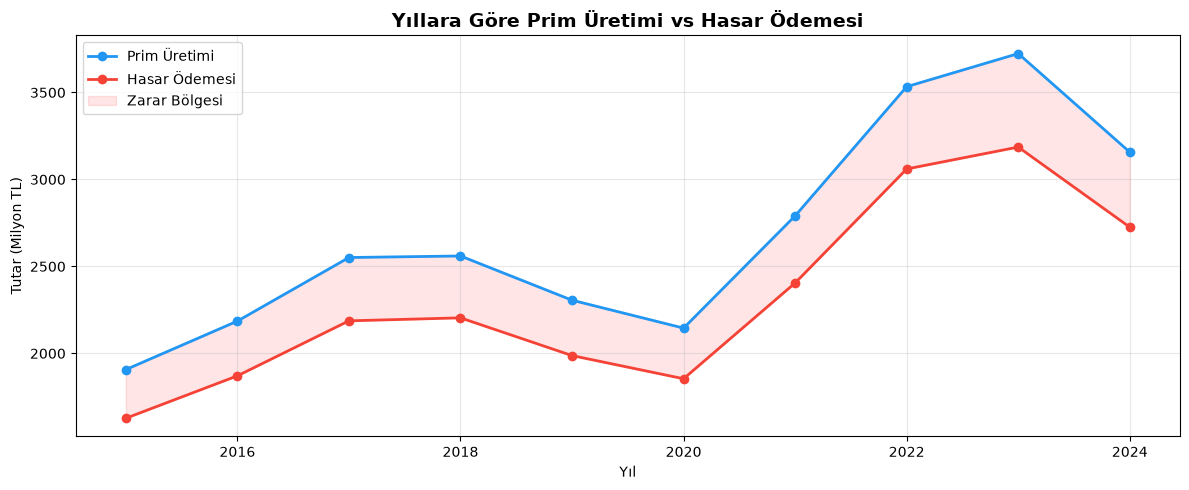

✅ Grafik kaydedildi!


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"] = "DejaVu Sans"

# Yıllara göre toplam prim ve hasar
yillik = df.groupby("yil")[["prim_tl", "hasar_tl"]].sum() / 1_000_000

fig, ax = plt.subplots()
ax.plot(yillik.index, yillik["prim_tl"], marker="o", label="Prim Üretimi", color="#2196F3", linewidth=2)
ax.plot(yillik.index, yillik["hasar_tl"], marker="o", label="Hasar Ödemesi", color="#F44336", linewidth=2)
ax.fill_between(yillik.index, yillik["prim_tl"], yillik["hasar_tl"], alpha=0.1, color="red", label="Zarar Bölgesi")

ax.set_title("Yıllara Göre Prim Üretimi vs Hasar Ödemesi", fontsize=14, fontweight="bold")
ax.set_xlabel("Yıl")
ax.set_ylabel("Tutar (Milyon TL)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/01_prim_hasar_trend.png", dpi=150)
plt.show()
print("✅ Grafik kaydedildi!")

In [8]:
import os
os.makedirs("outputs", exist_ok=True)
print("✅ outputs klasörü oluşturuldu!")

✅ outputs klasörü oluşturuldu!


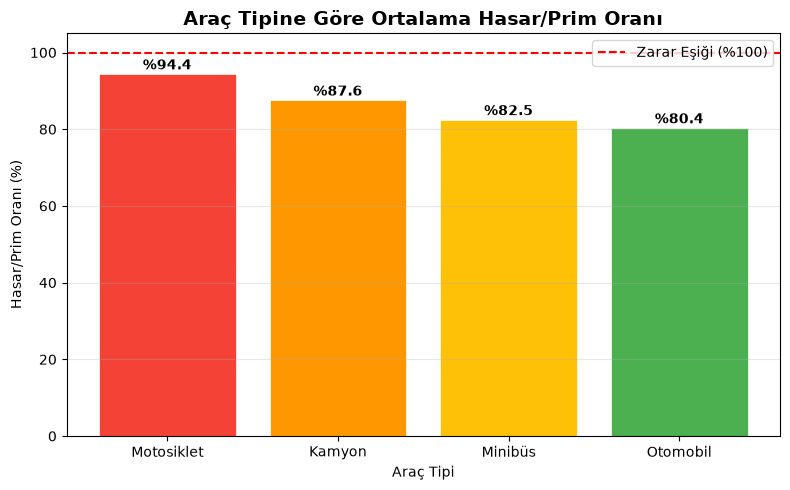

✅ Grafik kaydedildi!


In [9]:
# Araç tipine göre ortalama hasar/prim oranı
arac_hasar = df.groupby("arac_tipi")["hasar_prim_orani"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
renkler = ["#F44336", "#FF9800", "#FFC107", "#4CAF50"]
bars = ax.bar(arac_hasar.index, arac_hasar.values * 100, color=renkler, edgecolor="white", linewidth=0.5)

# Çubukların üstüne değer yaz
for bar, val in zip(bars, arac_hasar.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"%{val*100:.1f}", ha="center", va="bottom", fontweight="bold")

ax.axhline(y=100, color="red", linestyle="--", linewidth=1.5, label="Zarar Eşiği (%100)")
ax.set_title("Araç Tipine Göre Ortalama Hasar/Prim Oranı", fontsize=14, fontweight="bold")
ax.set_xlabel("Araç Tipi")
ax.set_ylabel("Hasar/Prim Oranı (%)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("outputs/02_arac_tipi_hasar.png", dpi=150)
plt.show()
print("✅ Grafik kaydedildi!")

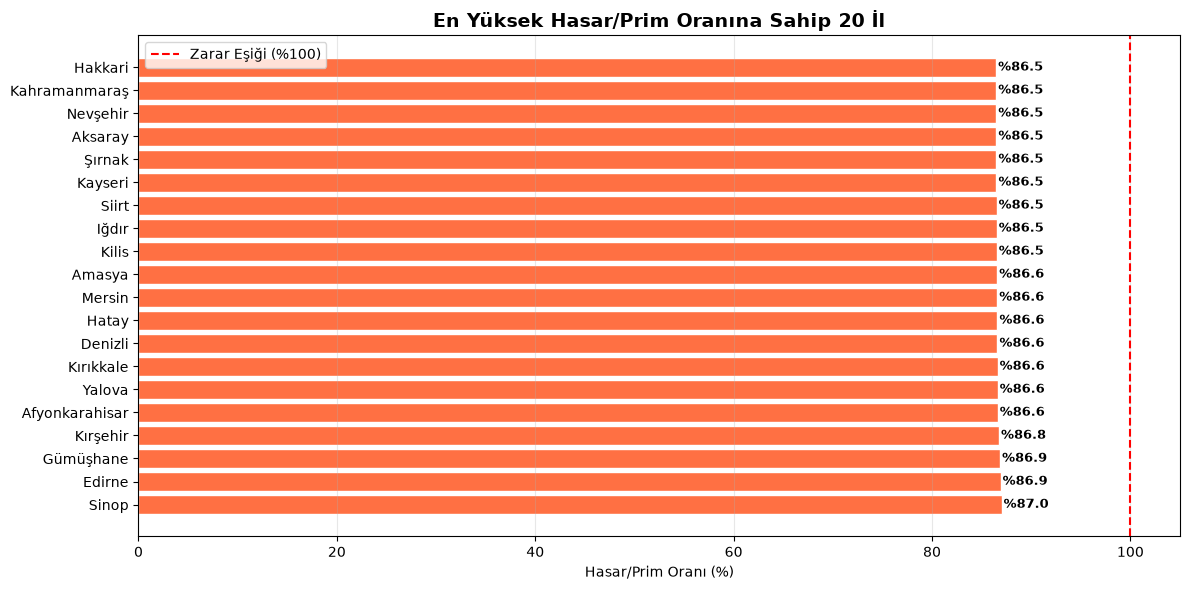

✅ Grafik kaydedildi!


In [10]:
# En yüksek hasar/prim oranına sahip 20 il
il_hasar = df.groupby("il")["hasar_prim_orani"].mean().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
renkler = ["#D32F2F" if x > 0.90 else "#FF7043" if x > 0.85 else "#FFA726" for x in il_hasar.values]

bars = ax.barh(il_hasar.index, il_hasar.values * 100, color=renkler, edgecolor="white")

for bar, val in zip(bars, il_hasar.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"%{val*100:.1f}", va="center", fontweight="bold", fontsize=9)

ax.axvline(x=100, color="red", linestyle="--", linewidth=1.5, label="Zarar Eşiği (%100)")
ax.set_title("En Yüksek Hasar/Prim Oranına Sahip 20 İl", fontsize=14, fontweight="bold")
ax.set_xlabel("Hasar/Prim Oranı (%)")
ax.legend()
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("outputs/03_il_bazli_hasar.png", dpi=150)
plt.show()
print("✅ Grafik kaydedildi!")

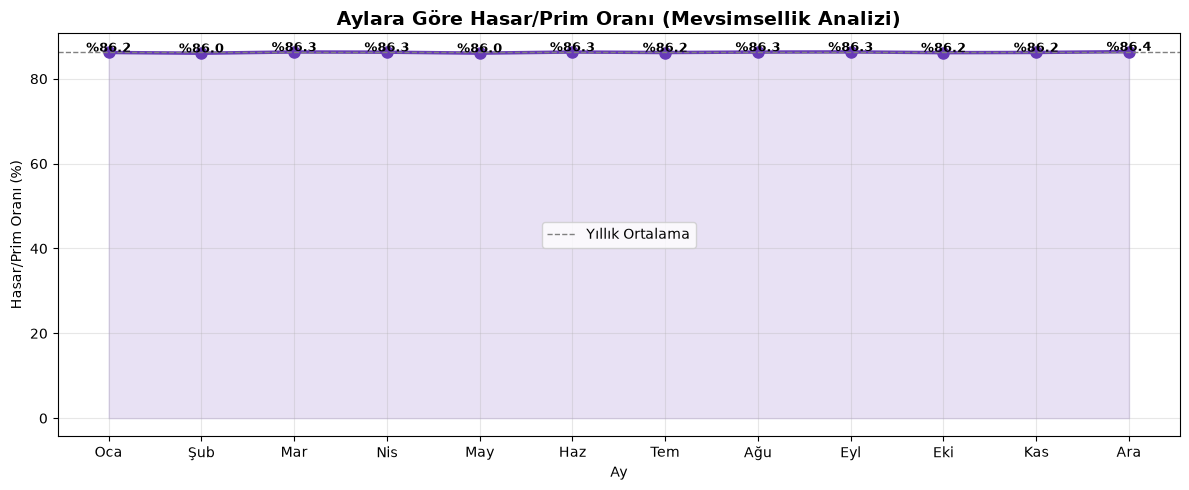

✅ Grafik kaydedildi!


In [11]:
# Aylık ortalama hasar/prim oranı (mevsimsellik analizi)
ay_isimleri = {1:"Oca", 2:"Şub", 3:"Mar", 4:"Nis", 5:"May", 6:"Haz",
               7:"Tem", 8:"Ağu", 9:"Eyl", 10:"Eki", 11:"Kas", 12:"Ara"}

aylik = df.groupby("ay")["hasar_prim_orani"].mean()
aylik.index = [ay_isimleri[i] for i in aylik.index]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(aylik.index, aylik.values * 100, marker="o", color="#673AB7", linewidth=2.5, markersize=8)
ax.fill_between(range(len(aylik)), aylik.values * 100, alpha=0.15, color="#673AB7")

for i, (ay, val) in enumerate(zip(aylik.index, aylik.values)):
    ax.text(i, val * 100 + 0.2, f"%{val*100:.1f}", ha="center", fontsize=9, fontweight="bold")

ax.axhline(y=aylik.values.mean() * 100, color="gray", linestyle="--", linewidth=1, label="Yıllık Ortalama")
ax.set_xticks(range(len(aylik)))
ax.set_xticklabels(aylik.index)
ax.set_title("Aylara Göre Hasar/Prim Oranı (Mevsimsellik Analizi)", fontsize=14, fontweight="bold")
ax.set_xlabel("Ay")
ax.set_ylabel("Hasar/Prim Oranı (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/04_aylik_mevsimsellik.png", dpi=150)
plt.show()
print("✅ Grafik kaydedildi!")

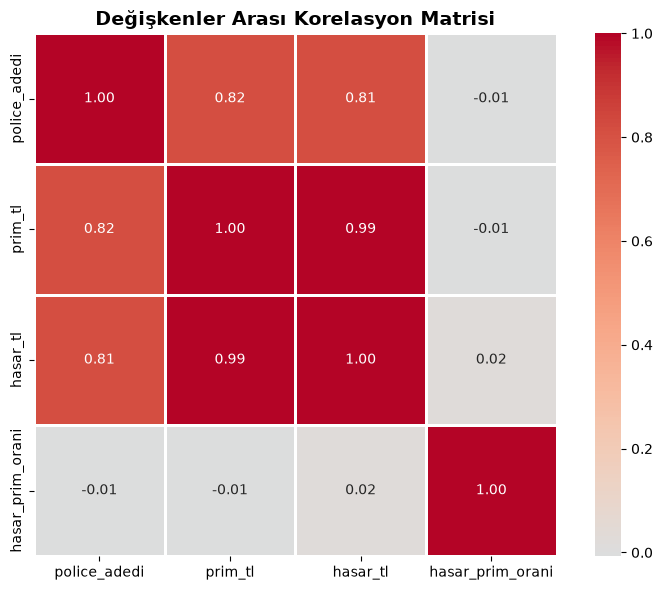

✅ Korelasyon matrisi kaydedildi!


In [13]:
import seaborn as sns

# Korelasyon matrisi için sayısal sütunlar
sayisal_df = df[["police_adedi", "prim_tl", "hasar_tl", "hasar_prim_orani"]]
korelasyon = sayisal_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(korelasyon, annot=True, cmap="coolwarm", center=0, 
            fmt=".2f", square=True, linewidths=1, ax=ax)
ax.set_title("Değişkenler Arası Korelasyon Matrisi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/05_korelasyon_matrisi.png", dpi=150)
plt.show()
print("✅ Korelasyon matrisi kaydedildi!")

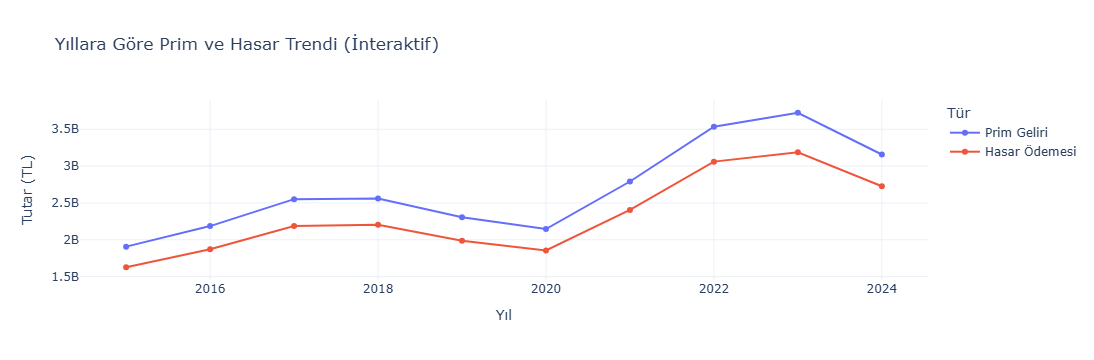

✅ İnteraktif grafik kaydedildi!


In [14]:
import plotly.express as px

# Yıllara göre prim vs hasar - interaktif
yillik_uzun = df.groupby("yil")[["prim_tl", "hasar_tl"]].sum().reset_index()
yillik_uzun = yillik_uzun.melt(id_vars="yil", var_name="Tür", value_name="Tutar")
yillik_uzun["Tür"] = yillik_uzun["Tür"].map({"prim_tl": "Prim Geliri", "hasar_tl": "Hasar Ödemesi"})

fig = px.line(yillik_uzun, x="yil", y="Tutar", color="Tür",
              title="Yıllara Göre Prim ve Hasar Trendi (İnteraktif)",
              labels={"yil": "Yıl", "Tutar": "Tutar (TL)"},
              markers=True)
fig.update_layout(hovermode="x unified", template="plotly_white")
fig.write_html("outputs/06_interaktif_trend.html")
fig.show()
print("✅ İnteraktif grafik kaydedildi!")